In [51]:
# compute disc implicit connectives metrics

# for each doc: tanh (num of unique connective types / num of types)
# averaged across docs

In [52]:
from pathlib import Path
import pandas as pd
import numpy as np

DISCOURSE_RELS_DIR = Path('/mimer/NOBACKUP/groups/naiss2025-22-1187/coherence-driven-humans/data/data_impl_connectives/')


In [53]:
def load_rels_data():
    all_data = []
    for folder in DISCOURSE_RELS_DIR.iterdir():
        if not folder.is_dir():
            continue
        rels_path = folder / "eng.pdtb.gum" / "eng.pdtb.gum_test.rels"
        if not rels_path.exists():
            continue
        # the output of the classifer produced a specific format
        parts = folder.name.split('_')
        model = parts[0]
        prompt = parts[1] if len(parts) > 1 else 'unknown'
        seed = parts[2] if len(parts) > 2 else None
        df = pd.read_csv(rels_path, sep='\t')
        df['model'] = model
        df['prompt'] = prompt
        df['seed'] = seed
        df['source_folder'] = folder.name
        all_data.append(df)
    return pd.concat(all_data, ignore_index=True)

def compute_discourse_diversity(df):
    prediction_col = 'prediction' if 'prediction' in df.columns else 'label'
    results = []
    groups = df.groupby(['model', 'prompt', 'seed', 'doc'], dropna=False)
    for (model, prompt, seed, doc), story_df in groups:
        relations = story_df[prediction_col].tolist()
        n_total = len(relations)
        n_none = sum(1 for r in relations if r in ['NONE', 'none', None, ''])
        valid_relations = [r for r in relations if r not in ['NONE', 'none', None, '']]

        if len(valid_relations) == 0:
            diversity_ratio = 0.0
            n_unique = 0
        else:
            n_unique = len(set(valid_relations))
            diversity_ratio = np.tanh(n_unique / len(valid_relations))

        none_rate = (n_none / n_total) if n_total > 0 else 0.0

        results.append({
            'model': model, 'prompt': prompt, 'seed': seed, 'doc': doc,
            'n_unique_relations': n_unique, 'n_total_relations': n_total,
            'n_none_relations': n_none, 'none_rate': none_rate,
            'discourse_diversity': diversity_ratio
        })
    return pd.DataFrame(results)


In [54]:
def prepare_discourse_data(diversity_df):
    # averaging across human seeds
    results = []
    for model in diversity_df['model'].unique():
        for prompt in diversity_df['prompt'].unique():
            subset = diversity_df[(diversity_df['model'] == model) & 
                                  (diversity_df['prompt'] == prompt)]
            if subset.empty:
                continue
            seeds = subset['seed'].dropna().unique()
            if len(seeds) > 1:
                story_avg = subset.groupby('doc').agg({
                    'n_unique_relations': 'mean',
                    'n_total_relations': 'mean',
                    'n_none_relations': 'mean',
                    'none_rate': 'mean',
                    'discourse_diversity': 'mean'
                }).reset_index()
                for _, row in story_avg.iterrows():
                    results.append({
                        'model': model, 'prompt': prompt, 'story_id': row['doc'],
                        'n_unique_relations': row['n_unique_relations'],
                        'n_total_relations': row['n_total_relations'],
                        'n_none_relations': row['n_none_relations'],
                        'none_rate': row['none_rate'],
                        'discourse_diversity': row['discourse_diversity']
                    })
            else:
                for _, row in subset.iterrows():
                    results.append({
                        'model': model, 'prompt': prompt, 'story_id': row['doc'],
                        'n_unique_relations': row['n_unique_relations'],
                        'n_total_relations': row['n_total_relations'],
                        'n_none_relations': row['n_none_relations'],
                        'none_rate': row['none_rate'],
                        'discourse_diversity': row['discourse_diversity']
                    })
    return pd.DataFrame(results)

In [55]:
df_rels_raw = load_rels_data()
print(df_rels_raw.head())

         doc unit1_toks unit2_toks  \
0  story_345        1-7       8-19   
1  story_345       8-19      20-26   
2  story_345      20-26      27-41   
3  story_345      27-41      42-52   
4  story_345      42-52      53-57   

                                           unit1_txt  \
0                     The scene is set in hospital .   
1  A doctor talks to a nurse at a nurse 's station .   
2                       A patient fills out a form .   
3  The nurse tells the doctor that two detectives...   
4  They recommend he comes down to the station fo...   

                                           unit2_txt  \
0  A doctor talks to a nurse at a nurse 's station .   
1                       A patient fills out a form .   
2  The nurse tells the doctor that two detectives...   
3  They recommend he comes down to the station fo...   
4                            The doctor is nervous .   

                                              u1_raw  \
0                     The scene is set in

In [56]:
df_diversity_raw = compute_discourse_diversity(df_rels_raw)
print(df_diversity_raw.head())

      model prompt seed          doc  n_unique_relations  n_total_relations  \
0  claude45  large  NaN  story_10408                   3                 11   
1  claude45  large  NaN  story_10486                   3                 11   
2  claude45  large  NaN  story_10499                   2                 13   
3  claude45  large  NaN   story_1111                   2                 17   
4  claude45  large  NaN  story_11260                   2                  4   

   n_none_relations  none_rate  discourse_diversity  
0                 0        0.0             0.266161  
1                 0        0.0             0.266161  
2                 0        0.0             0.152644  
3                 0        0.0             0.117107  
4                 0        0.0             0.462117  


In [57]:
df_discourse = prepare_discourse_data(df_diversity_raw)
print(df_discourse.head())


      model prompt     story_id  n_unique_relations  n_total_relations  \
0  claude45  large  story_10408                 3.0               11.0   
1  claude45  large  story_10486                 3.0               11.0   
2  claude45  large  story_10499                 2.0               13.0   
3  claude45  large   story_1111                 2.0               17.0   
4  claude45  large  story_11260                 2.0                4.0   

   n_none_relations  none_rate  discourse_diversity  
0               0.0        0.0             0.266161  
1               0.0        0.0             0.266161  
2               0.0        0.0             0.152644  
3               0.0        0.0             0.117107  
4               0.0        0.0             0.462117  


In [58]:
discourse_agg = (
    df_discourse.groupby(['model', 'prompt'])
    .agg(
        n_unique_relations=('n_unique_relations', 'mean'),
        n_total_relations=('n_total_relations', 'mean'),
        n_none_relations=('n_none_relations', 'mean'),
        none_rate=('none_rate', 'mean'),
        discourse_diversity_mean=('discourse_diversity', 'mean'),
        discourse_diversity_std=('discourse_diversity', 'std'),
        count=('discourse_diversity', 'count')
    )
    .reset_index()
)

In [59]:
discourse_agg

,model,prompt,n_unique_relations,n_total_relations,n_none_relations,none_rate,discourse_diversity_mean,discourse_diversity_std,count
0,claude45,large,2.733333,11.283333,0.0,0.0,0.268482,0.117414,60
1,claude45,original,3.000000,10.816667,0.0,0.0,0.282541,0.084400,60
2,gpt4o,large,2.866667,8.750000,0.0,0.0,0.320452,0.077081,60
3,gpt4o,original,3.366667,11.366667,0.0,0.0,0.291879,0.063894,60
4,human,large,3.355556,10.744444,0.0,0.0,0.340584,0.082517,60
5,human,original,2.500000,5.300000,0.0,0.0,0.452158,0.140900,60
6,internvl3,large,3.216667,12.766667,0.0,0.0,0.276231,0.104649,60
7,internvl3,original,3.283333,13.683333,0.0,0.0,0.248980,0.068648,60
8,llama4scout,large,2.666667,7.750000,0.0,0.0,0.357218,0.120032,60
9,llama4scout,original,3.350000,10.233333,0.0,0.0,0.333921,0.096016,60


In [60]:
# num total relations: how many implicit discourse relation types the story contains
# num of unique relations: how many different unique discourse relation types are identified

# discourse diversity: tanh (num total relations / n unique relations)

# squashed between 0 and 1, there are no NONE relations, meaning that every pair of sentences has some relation, according to the classifier
# values near 1: high type diversity, uses a wider mix of implicit relation types
# values near 0: low diversity, repeats the same few relation types

# reporting together with n_total relations is important, because high diversity with low totals could show high relation type variety achieved in shorter text (e.g. human original).


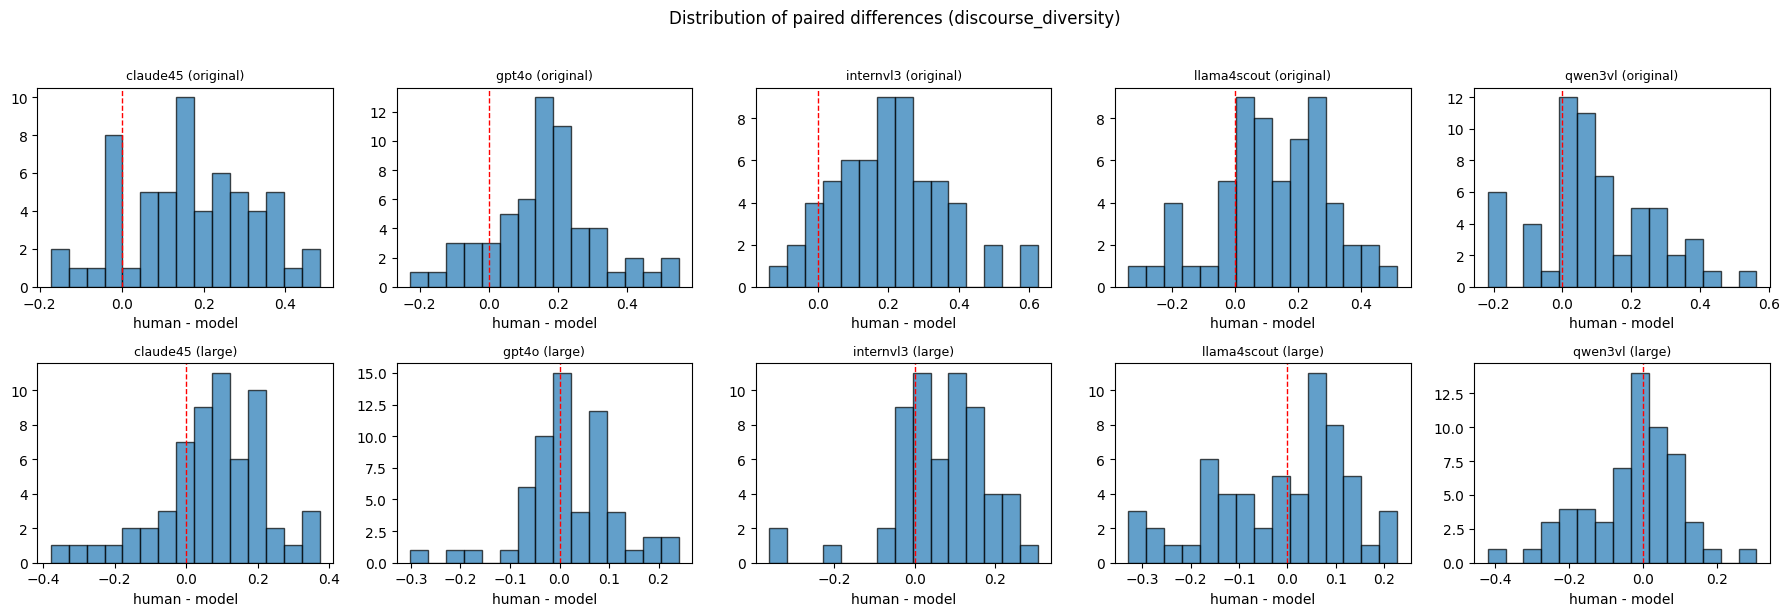

In [61]:
# visualising the distribution of diversity differences between humans and each model
# check shape of paired differences before/alongside t-tests

import matplotlib.pyplot as plt

MODELS = ['human', 'claude45', 'gpt4o', 'internvl3', 'llama4scout', 'qwen3vl']
PROMPTS = ['original', 'large']

fig, axes = plt.subplots(len(PROMPTS), len(MODELS) - 1, figsize=(18, 6), squeeze=False)

for i, prompt in enumerate(PROMPTS):
    df_human = df_discourse[(df_discourse['model'] == 'human') & (df_discourse['prompt'] == prompt)].set_index('story_id')
    col = 0
    for model in MODELS:
        if model == 'human':
            continue
        df_model = df_discourse[(df_discourse['model'] == model) & (df_discourse['prompt'] == prompt)].set_index('story_id')
        common_ids = df_human.index.intersection(df_model.index)

        diffs = df_human.loc[common_ids, 'discourse_diversity'].values - df_model.loc[common_ids, 'discourse_diversity'].values

        ax = axes[i][col]
        ax.hist(diffs, bins=15, edgecolor='black', alpha=0.7)
        ax.axvline(0, color='red', linestyle='--', linewidth=1)
        ax.set_title(f"{model} ({prompt})", fontsize=9)
        ax.set_xlabel('human - model')
        col += 1

plt.suptitle('Distribution of paired differences (discourse_diversity)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [62]:
from scipy.stats import ttest_rel

MODELS = ['human', 'claude45', 'gpt4o', 'internvl3', 'llama4scout', 'qwen3vl']
PROMPTS = ['original', 'large']

# Paired t-test per prompt, paired by story_id
# Models vs Humans
# do VLMs produce stories with different implicit discourse diversity than humans?
# do VLMs vary implicit relation types differently than humans?

model_vs_human_results = []
for prompt in PROMPTS:
    print(f"--- Prompt: {prompt} ---")
    df_human = df_discourse[(df_discourse['model'] == 'human') & (df_discourse['prompt'] == prompt)].set_index('story_id')

    for model in MODELS:
        if model == 'human':
            continue
        df_model = df_discourse[(df_discourse['model'] == model) & (df_discourse['prompt'] == prompt)].set_index('story_id')

        common_ids = df_human.index.intersection(df_model.index)
        if len(common_ids) == 0:
            print(f"  {model}: no common story_ids")
            continue

        human_vals = df_human.loc[common_ids, 'discourse_diversity'].values
        model_vals = df_model.loc[common_ids, 'discourse_diversity'].values

        stat, p = ttest_rel(human_vals, model_vals)
        direction = "model > human" if np.mean(model_vals) > np.mean(human_vals) else "model < human"
        print(f"  {model:15s}  t={stat:.3f}  p={p:.4f}  n={len(common_ids)}  ({direction})")
    print()


--- Prompt: original ---
  claude45         t=8.544  p=0.0000  n=60  (model < human)
  gpt4o            t=7.829  p=0.0000  n=60  (model < human)
  internvl3        t=9.871  p=0.0000  n=60  (model < human)
  llama4scout      t=5.149  p=0.0000  n=60  (model < human)
  qwen3vl          t=4.295  p=0.0001  n=60  (model < human)

--- Prompt: large ---
  claude45         t=3.757  p=0.0004  n=60  (model < human)
  gpt4o            t=1.642  p=0.1058  n=60  (model < human)
  internvl3        t=4.017  p=0.0002  n=60  (model < human)
  llama4scout      t=-0.923  p=0.3599  n=60  (model > human)
  qwen3vl          t=-1.737  p=0.0876  n=60  (model > human)



In [63]:
# overall, humans have significantly higher diversity than models, especially in the original prompt
# however, what's important to note is that humans produce shorter text in that prompt
# in large prompt, humans are higher than some models, but not significantly different from others

In [64]:
# Paired t-test per prompt, paired by story_id
# Original vs Large prompt
# do VLMs differ in their implicit connective diversity across prompts?

for model in MODELS:
    df_orig = df_discourse[(df_discourse['model'] == model) & (df_discourse['prompt'] == 'original')].set_index('story_id')
    df_large = df_discourse[(df_discourse['model'] == model) & (df_discourse['prompt'] == 'large')].set_index('story_id')
    
    common_ids = df_orig.index.intersection(df_large.index)
    if len(common_ids) == 0:
        print(f"  {model}: no common story_ids")
        continue
    
    orig_vals = df_orig.loc[common_ids, 'discourse_diversity'].values
    large_vals = df_large.loc[common_ids, 'discourse_diversity'].values
    
    stat, p = ttest_rel(orig_vals, large_vals)
    direction = "large > original" if np.mean(large_vals) > np.mean(orig_vals) else "large < original"
    print(f"  {model:15s}  t={stat:.3f}  p={p:.4f}  n={len(common_ids)}  ({direction})")

  human            t=5.486  p=0.0000  n=60  (large < original)
  claude45         t=0.761  p=0.4495  n=60  (large < original)
  gpt4o            t=-2.410  p=0.0191  n=60  (large > original)
  internvl3        t=-1.790  p=0.0786  n=60  (large > original)
  llama4scout      t=-1.277  p=0.2065  n=60  (large > original)
  qwen3vl          t=-0.611  p=0.5435  n=60  (large > original)


In [ ]:
# humans experience significant change with prompt change, decrease in diversity when they move to the large prompt
# gpt4 has significant increase, on the contrary to humans
# other models are not really affected
# and this is the difference between models and humans, that in human behaviour, large prompt results in longer texts, which also means lower diversity (expected)
# models don't really demonstrate that (gpt4o behaves differently, and other models are just not sensitive to the prompt change)

In [66]:
discdata_path = Path('./analysis_data/implicit_connectives/')
discdata_path.mkdir(parents=True, exist_ok=True)

df_rels_raw.to_csv(discdata_path / 'rels_raw.csv', index=False)
df_diversity_raw.to_csv(discdata_path / 'discourse_diversity_raw.csv', index=False)
df_discourse.to_csv(discdata_path / 'discourse_metrics.csv', index=False)
discourse_agg.to_csv(discdata_path / 'discourse_metrics_agg.csv', index=False)

print(f"Saved implicit-connectives outputs to {discdata_path}")

Saved implicit-connectives outputs to analysis_data/implicit_connectives
